In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
result_df = pd.read_csv('result.csv')
result_df.head() 

,0,1,2,3,4,5,6
0,货币名称,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,发布时间
1,美元,715.3,715.15,718.15,718.15,710.1,2024.01.09 21:25:42
2,美元,715.3,715.15,718.15,718.15,710.1,2024.01.09 21:15:08
3,美元,715.3,715.15,718.15,718.15,710.1,2024.01.09 21:11:54
4,美元,715.3,715.15,718.15,718.15,710.1,2024.01.09 20:53:15


In [3]:
columns = ['现汇买入价', '现钞买入价', '现汇卖出价', '现钞卖出价', '中行折算价', '发布时间']
result_df = pd.read_csv('result.csv', names = columns)
result_df.head()

,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,发布时间
0,1,2,3,4,5,6
货币名称,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,发布时间
美元,715.3,715.15,718.15,718.15,710.1,2024.01.09 21:25:42
美元,715.3,715.15,718.15,718.15,710.1,2024.01.09 21:15:08
美元,715.3,715.15,718.15,718.15,710.1,2024.01.09 21:11:54


In [4]:
result_df.drop("0", axis=0,inplace=True)
result_df.drop("货币名称", axis=0, inplace=True)
result_df['发布时间'] = pd.to_datetime(result_df['发布时间'])
result_df['发布时间'] = result_df['发布时间'].dt.date
result_df

,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,发布时间
美元,715.3,715.15,718.15,718.15,710.1,2024-01-09
美元,715.3,715.15,718.15,718.15,710.1,2024-01-09
美元,715.3,715.15,718.15,718.15,710.1,2024-01-09
美元,715.3,715.15,718.15,718.15,710.1,2024-01-09
美元,715.25,715.1,718.1,718.1,710.1,2024-01-09
美元,715.2,715.05,718.05,718.05,710.1,2024-01-09
美元,715.2,715.05,718.05,718.05,710.1,2024-01-09
美元,715.25,715.1,718.1,718.1,710.1,2024-01-09
美元,715.25,715.1,718.1,718.1,710.1,2024-01-09
美元,715.15,715,718,718,710.1,2024-01-09


In [5]:
result_df = result_df.reset_index(drop=True)
result_df = result_df.astype(
    {
        "现汇买入价": "float",
        "现钞买入价": "float",
        "现汇卖出价": "float",
        "现钞卖出价": "float",
        "中行折算价": "float",
    }
)


In [6]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57721 entries, 0 to 57720
Data columns (total 6 columns):
现汇买入价    57721 non-null float64
现钞买入价    57721 non-null float64
现汇卖出价    57721 non-null float64
现钞卖出价    57721 non-null float64
中行折算价    57721 non-null float64
发布时间     57721 non-null object
dtypes: float64(5), object(1)
memory usage: 2.6+ MB


In [7]:
result_df = result_df.groupby(["发布时间"], sort=True)
# result_df = result_df.apply(lambda x:x.sort_values("发布时间"))
# result_df.head(100) 

In [8]:
avg_price = result_df.mean()
avg_price.head() 

,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价
发布时间,,,,,
2023-01-09,676.967015,671.460373,679.834179,679.834179,683.084552
2023-01-10,676.236846,670.734808,679.099462,679.099462,676.688538
2023-01-11,676.282905,670.779333,679.144619,679.144619,677.497857
2023-01-12,674.472000,668.984966,677.331724,677.331724,676.826207
2023-01-19,677.183167,671.676333,680.052667,680.052667,676.740000


In [9]:
avg_price['现钞买入汇率'] = 100.0 / avg_price['现钞买入价']
avg_price['现汇卖出汇率'] = 100.0 / avg_price['现汇卖出价']
avg_price['中行折算汇率'] = 100.0 / avg_price['中行折算价']
avg_price.head() 

,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,现钞买入汇率,现汇卖出汇率,中行折算汇率
发布时间,,,,,,,,
2023-01-09,676.967015,671.460373,679.834179,679.834179,683.084552,0.148929,0.147095,0.146395
2023-01-10,676.236846,670.734808,679.099462,679.099462,676.688538,0.149090,0.147254,0.147778
2023-01-11,676.282905,670.779333,679.144619,679.144619,677.497857,0.149080,0.147244,0.147602
2023-01-12,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748
2023-01-19,677.183167,671.676333,680.052667,680.052667,676.740000,0.148881,0.147047,0.147767


In [10]:
avg_price.index = pd.to_datetime(avg_price.index) 
avg_price = avg_price.resample("D").ffill()
avg_price.head(10) 

,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,现钞买入汇率,现汇卖出汇率,中行折算汇率
发布时间,,,,,,,,
2023-01-09,676.967015,671.460373,679.834179,679.834179,683.084552,0.148929,0.147095,0.146395
2023-01-10,676.236846,670.734808,679.099462,679.099462,676.688538,0.149090,0.147254,0.147778
2023-01-11,676.282905,670.779333,679.144619,679.144619,677.497857,0.149080,0.147244,0.147602
2023-01-12,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748
2023-01-13,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748
2023-01-14,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748
2023-01-15,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748
2023-01-16,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748
2023-01-17,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748


In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

result_df = pd.read_csv('result.csv')
columns = ['现汇买入价', '现钞买入价', '现汇卖出价', '现钞卖出价', '中行折算价', '发布时间']
result_df = pd.read_csv('result.csv', names = columns)
result_df.drop("0", axis=0,inplace=True)
result_df.drop("货币名称", axis=0, inplace=True)
result_df['发布时间'] = pd.to_datetime(result_df['发布时间'])
result_df['发布时间'] = result_df['发布时间'].dt.date
result_df
result_df = result_df.reset_index(drop=True)
result_df = result_df.astype(
{
"现汇买入价": "float",
"现钞买入价": "float",
"现汇卖出价": "float",
"现钞卖出价": "float",
"中行折算价": "float",
}
)
result_df = result_df.groupby(["发布时间"], sort=True)
avg_price = result_df.mean()
avg_price['现钞买入汇率'] = 100.0 / avg_price['现钞买入价']
avg_price['现汇卖出汇率'] = 100.0 / avg_price['现汇卖出价']
avg_price['中行折算汇率'] = 100.0 / avg_price['中行折算价']
avg_price.index = pd.to_datetime(avg_price.index)
avg_price = avg_price.resample("D").ffill()
avg_price['汇率变化率'] = ((avg_price['中行折算汇率'] - avg_price['中行折算汇率'].shift(1))/(avg_price['中行折算汇率']))*100
avg_price['汇率变化率'] = avg_price['汇率变化率'].round(5)
avg_price['汇率变化率'][0] = 0
avg_price


,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,现钞买入汇率,现汇卖出汇率,中行折算汇率,汇率变化率
发布时间,,,,,,,,,
2023-01-09,676.967015,671.460373,679.834179,679.834179,683.084552,0.148929,0.147095,0.146395,0.00000
2023-01-10,676.236846,670.734808,679.099462,679.099462,676.688538,0.149090,0.147254,0.147778,0.93634
2023-01-11,676.282905,670.779333,679.144619,679.144619,677.497857,0.149080,0.147244,0.147602,-0.11960
2023-01-12,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.09914
2023-01-13,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000
2023-01-14,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000
2023-01-15,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000
2023-01-16,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000
2023-01-17,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000


In [12]:
avg_price['年份'] = avg_price.index.year
avg_price['月份'] = avg_price.index.month
#avg_price['日'] = avg_price.index.day
#avg_price['月-日'] = avg_price['月份'].astype(str) + '-' + avg_price['日'].astype(str)
avg_price['日期'] = avg_price.index.astype(int)
avg_price

,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,现钞买入汇率,现汇卖出汇率,中行折算汇率,汇率变化率,年份,月份,日期
发布时间,,,,,,,,,,,,
2023-01-09,676.967015,671.460373,679.834179,679.834179,683.084552,0.148929,0.147095,0.146395,0.00000,2023,1,1673222400000000000
2023-01-10,676.236846,670.734808,679.099462,679.099462,676.688538,0.149090,0.147254,0.147778,0.93634,2023,1,1673308800000000000
2023-01-11,676.282905,670.779333,679.144619,679.144619,677.497857,0.149080,0.147244,0.147602,-0.11960,2023,1,1673395200000000000
2023-01-12,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.09914,2023,1,1673481600000000000
2023-01-13,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023,1,1673568000000000000
2023-01-14,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023,1,1673654400000000000
2023-01-15,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023,1,1673740800000000000
2023-01-16,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023,1,1673827200000000000
2023-01-17,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023,1,1673913600000000000


C:\ana3\lib\site-packages\matplotlib\collections.py:922: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
C:\ana3\lib\site-packages\pandas\plotting\_tools.py:307: MatplotlibDeprecationWarning: 
The rowNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().rowspan.start instead.
  layout[ax.rowNum, ax.colNum] = ax.get_visible()
C:\ana3\lib\site-packages\pandas\plotting\_tools.py:307: MatplotlibDeprecationWarning: 
The colNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().colspan.start instead.
  layout[ax.rowNum, ax.colNum] = ax.get_visible()
C:\ana3\lib\site-packages\pandas\plotting\_tools.py:313: MatplotlibDeprecationWarning: 
The rowNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().rowspan.start instead.
  if not layout[ax.rowNum 

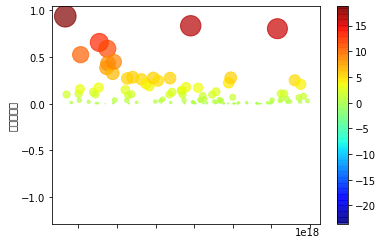

In [13]:
df_co = avg_price.copy() 
df_co.plot(kind="scatter", x="日期", y="汇率变化率",
            s=df_co["汇率变化率"]*500,
            c=df_co["汇率变化率"]*20,
            alpha=0.7,
            cmap=plt.get_cmap("jet"),
            colorbar=True
            )
plt.show() 

C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 26085 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 26399 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 27719 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 29575 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 21464 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 21270 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backen

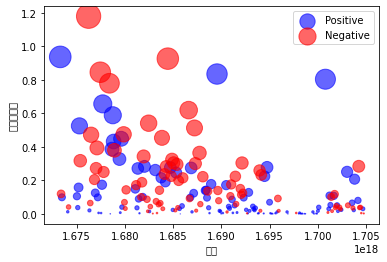

In [14]:
# 复制数据框
df_co = avg_price.copy() 

# 绘制散点图
fig, ax = plt.subplots()
positive_values = df_co[df_co["汇率变化率"] >= 0]
negative_values = df_co[df_co["汇率变化率"] < 0]

ax.scatter(positive_values["日期"], positive_values["汇率变化率"].abs(), 
           s=positive_values["汇率变化率"].abs()*500, c='b', alpha=0.6, label='Positive')

ax.scatter(negative_values["日期"], negative_values["汇率变化率"].abs(), 
           s=negative_values["汇率变化率"].abs()*500, c='r', alpha=0.6, label='Negative')

ax.set_xlabel('日期')
ax.set_ylabel('汇率变化率')
ax.legend()
plt.show() 

In [15]:
avg_price_day1 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 1)].mean()
avg_price_day2 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 2)].mean()
avg_price_day3 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 3)].mean()
avg_price_day4 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 4)].mean()
avg_price_day5 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 5)].mean()
avg_price_day6 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 6)].mean()
avg_price_day7 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 7)].mean()
avg_price_day8 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 8)].mean()
avg_price_day9 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 9)].mean()
avg_price_day10 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 10)].mean()
avg_price_day11 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 11)].mean()
avg_price_day12 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 12)].mean()
avg_price_day13 = avg_price[(avg_price['年份'] == 2024) & (avg_price['月份'] == 1)].mean()
df_list = [avg_price_day1,avg_price_day2,avg_price_day3,avg_price_day4,avg_price_day5,avg_price_day6,avg_price_day7,avg_price_day8,avg_price_day9,avg_price_day10,avg_price_day11,avg_price_day12,avg_price_day13]

df_list

[现汇买入价     6.760159e+02
 现钞买入价     6.705179e+02
 现汇卖出价     6.788826e+02
 现钞卖出价     6.788826e+02
 中行折算价     6.771457e+02
 现钞买入汇率    1.491393e-01
 现汇卖出汇率    1.473017e-01
 中行折算汇率    1.476792e-01
 汇率变化率     4.480174e-02
 年份        2.023000e+03
 月份        1.000000e+00
 日期        1.674173e+18
 dtype: float64, 现汇买入价     6.812438e+02
 现钞买入价     6.757019e+02
 现汇卖出价     6.841325e+02
 现钞卖出价     6.841325e+02
 中行折算价     6.812594e+02
 现钞买入汇率    1.480145e-01
 现汇卖出汇率    1.461906e-01
 中行折算汇率    1.468043e-01
 汇率变化率    -1.003404e-01
 年份        2.023000e+03
 月份        2.000000e+00
 日期        1.676376e+18
 dtype: float64, 现汇买入价     6.881753e+02
 现钞买入价     6.825778e+02
 现汇卖出价     6.910916e+02
 现钞卖出价     6.910916e+02
 中行折算价     6.897864e+02
 现钞买入汇率    1.465048e-01
 现汇卖出汇率    1.446999e-01
 中行折算汇率    1.449757e-01
 汇率变化率     3.008839e-02
 年份        2.023000e+03
 月份        3.000000e+00
 日期        1.678925e+18
 dtype: float64, 现汇买入价     6.882061e+02
 现钞买入价     6.826077e+02
 现汇卖出价     6.911236e+02
 现钞卖出价     6.911

In [16]:
df = pd.DataFrame(df_list)
df

,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,现钞买入汇率,现汇卖出汇率,中行折算汇率,汇率变化率,年份,月份,日期
0,676.015942,670.517920,678.882591,678.882591,677.145714,0.149139,0.147302,0.147679,0.044802,2023.0,1.0,1.674173e+18
1,681.243777,675.701907,684.132510,684.132510,681.259356,0.148015,0.146191,0.146804,-0.100340,2023.0,2.0,1.676376e+18
2,688.175263,682.577783,691.091638,691.091638,689.786350,0.146505,0.144700,0.144976,0.030088,2023.0,3.0,1.678925e+18
3,688.206112,682.607658,691.123576,691.123576,688.709349,0.146498,0.144693,0.145200,-0.018056,2023.0,4.0,1.681560e+18
4,697.476034,691.802754,700.432423,700.432423,698.401088,0.144562,0.142781,0.143196,-0.073193,2023.0,5.0,1.684195e+18
5,713.817272,708.011051,716.843667,716.843667,714.286165,0.141247,0.139507,0.140005,-0.067149,2023.0,6.0,1.686830e+18
6,719.504672,713.650785,722.495132,722.495132,717.302611,0.140128,0.138412,0.139414,0.042619,2023.0,7.0,1.689466e+18
7,723.541379,717.656471,726.426638,726.426638,717.300208,0.139349,0.137666,0.139413,-0.022891,2023.0,8.0,1.692144e+18
8,728.777699,722.847486,731.681853,731.681853,718.491171,0.138343,0.136673,0.139181,0.000670,2023.0,9.0,1.694779e+18
9,729.408543,725.526282,732.317666,732.317666,717.902879,0.137834,0.136553,0.139295,0.000788,2023.0,10.0,1.697414e+18


In [17]:
df['年份'] = df['年份'].astype(int)
df['月份'] = df['月份'].astype(int)
df

,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,现钞买入汇率,现汇卖出汇率,中行折算汇率,汇率变化率,年份,月份,日期
0,676.015942,670.517920,678.882591,678.882591,677.145714,0.149139,0.147302,0.147679,0.044802,2023,1,1.674173e+18
1,681.243777,675.701907,684.132510,684.132510,681.259356,0.148015,0.146191,0.146804,-0.100340,2023,2,1.676376e+18
2,688.175263,682.577783,691.091638,691.091638,689.786350,0.146505,0.144700,0.144976,0.030088,2023,3,1.678925e+18
3,688.206112,682.607658,691.123576,691.123576,688.709349,0.146498,0.144693,0.145200,-0.018056,2023,4,1.681560e+18
4,697.476034,691.802754,700.432423,700.432423,698.401088,0.144562,0.142781,0.143196,-0.073193,2023,5,1.684195e+18
5,713.817272,708.011051,716.843667,716.843667,714.286165,0.141247,0.139507,0.140005,-0.067149,2023,6,1.686830e+18
6,719.504672,713.650785,722.495132,722.495132,717.302611,0.140128,0.138412,0.139414,0.042619,2023,7,1.689466e+18
7,723.541379,717.656471,726.426638,726.426638,717.300208,0.139349,0.137666,0.139413,-0.022891,2023,8,1.692144e+18
8,728.777699,722.847486,731.681853,731.681853,718.491171,0.138343,0.136673,0.139181,0.000670,2023,9,1.694779e+18
9,729.408543,725.526282,732.317666,732.317666,717.902879,0.137834,0.136553,0.139295,0.000788,2023,10,1.697414e+18


In [18]:
df_copy = df.copy() 
df_copy['年份-月份'] = df_copy['年份'].astype(str) + '-' + df_copy['月份'].astype(str)
df_copy

,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,现钞买入汇率,现汇卖出汇率,中行折算汇率,汇率变化率,年份,月份,日期,年份-月份
0,676.015942,670.517920,678.882591,678.882591,677.145714,0.149139,0.147302,0.147679,0.044802,2023,1,1.674173e+18,2023-1
1,681.243777,675.701907,684.132510,684.132510,681.259356,0.148015,0.146191,0.146804,-0.100340,2023,2,1.676376e+18,2023-2
2,688.175263,682.577783,691.091638,691.091638,689.786350,0.146505,0.144700,0.144976,0.030088,2023,3,1.678925e+18,2023-3
3,688.206112,682.607658,691.123576,691.123576,688.709349,0.146498,0.144693,0.145200,-0.018056,2023,4,1.681560e+18,2023-4
4,697.476034,691.802754,700.432423,700.432423,698.401088,0.144562,0.142781,0.143196,-0.073193,2023,5,1.684195e+18,2023-5
5,713.817272,708.011051,716.843667,716.843667,714.286165,0.141247,0.139507,0.140005,-0.067149,2023,6,1.686830e+18,2023-6
6,719.504672,713.650785,722.495132,722.495132,717.302611,0.140128,0.138412,0.139414,0.042619,2023,7,1.689466e+18,2023-7
7,723.541379,717.656471,726.426638,726.426638,717.300208,0.139349,0.137666,0.139413,-0.022891,2023,8,1.692144e+18,2023-8
8,728.777699,722.847486,731.681853,731.681853,718.491171,0.138343,0.136673,0.139181,0.000670,2023,9,1.694779e+18,2023-9
9,729.408543,725.526282,732.317666,732.317666,717.902879,0.137834,0.136553,0.139295,0.000788,2023,10,1.697414e+18,2023-10


C:\ana3\lib\site-packages\pandas\plotting\_tools.py:307: MatplotlibDeprecationWarning: 
The rowNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().rowspan.start instead.
  layout[ax.rowNum, ax.colNum] = ax.get_visible()
C:\ana3\lib\site-packages\pandas\plotting\_tools.py:307: MatplotlibDeprecationWarning: 
The colNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().colspan.start instead.
  layout[ax.rowNum, ax.colNum] = ax.get_visible()
C:\ana3\lib\site-packages\pandas\plotting\_tools.py:313: MatplotlibDeprecationWarning: 
The rowNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().rowspan.start instead.
  if not layout[ax.rowNum + 1, ax.colNum]:
C:\ana3\lib\site-packages\pandas\plotting\_tools.py:313: MatplotlibDeprecationWarning: 
The colNum attribute was deprecated in Matplotlib 3.2 and wil

ConversionError: Failed to convert value(s) to axis units: 0      2023-1
1      2023-2
2      2023-3
3      2023-4
4      2023-5
5      2023-6
6      2023-7
7      2023-8
8      2023-9
9     2023-10
10    2023-11
11    2023-12
12     2024-1
Name: 年份-月份, dtype: object

C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 29616 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 38046 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20080 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 20837 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 27719 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 29575 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\ana3\lib\site-packages\matplotlib\backends\backen

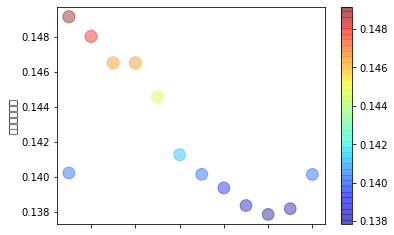

In [19]:
df_copy.plot(kind="scatter", x="月份", y="现钞买入汇率",
            s=df_copy["现钞买入汇率"]*1000,
            c=df_copy["现钞买入汇率"],
            alpha=0.4,
            cmap=plt.get_cmap("jet"),
            colorbar=True
            )
plt.xticks(df_copy['年份-月份']) 
plt.show() 

In [20]:
avg_price['年份'] = avg_price.index.year
avg_price['月份'] = avg_price.index.month
avg_price_monthly = avg_price.groupby(['年份', '月份']).mean()
avg_price_monthly.head(13) 

现汇买入价       现钞买入价       现汇卖出价       现钞卖出价       中行折算价    现钞买入汇率  \
年份   月份                                                                         
2023 1   676.015942  670.517920  678.882591  678.882591  677.145714  0.149139   
     2   681.243777  675.701907  684.132510  684.132510  681.259356  0.148015   
     3   688.175263  682.577783  691.091638  691.091638  689.786350  0.146505   
     4   688.206112  682.607658  691.123576  691.123576  688.709349  0.146498   
     5   697.476034  691.802754  700.432423  700.432423  698.401088  0.144562   
     6   713.817272  708.011051  716.843667  716.843667  714.286165  0.141247   
     7   719.504672  713.650785  722.495132  722.495132  717.302611  0.140128   
     8   723.541379  717.656471  726.426638  726.426638  717.300208  0.139349   
     9   728.777699  722.847486  731.681853  731.681853  718.491171  0.138343   
     10  729.408543  725.526282  732.317666  732.317666  717.902879  0.137834   
     11  724.010255  723.849726  726.896511  726.896511  716.087481  0.138161   
     12  713.842091  713.683944  716.688616  716.688616  710.637370  0.140120   
2024 1   713.416748  713.261027  716.259627  716.259627  709.628488  0.140202   

           现汇卖出汇率    中行折算汇率     汇率变化率                   日期  
年份   月份                                                     
2023 1   0.147302  0.147679  0.044802  1674172800000000000  
     2   0.146191  0.146804 -0.100340  1676376000000000000  
     3   0.144700  0.144976  0.030088  1678924800000000000  
     4   0.144693  0.145200 -0.018056  1681560000000000000  
     5   0.142781  0.143196 -0.073193  1684195200000000000  
     6   0.139507  0.140005 -0.067149  1686830400000000000  
     7   0.138412  0.139414  0.042619  1689465600000000000  
     8   0.137666  0.139413 -0.022891  1692144000000000000  
     9   0.136673  0.139181  0.000670  1694779200000000000  
     10  0.136553  0.139295  0.000788  1697414400000000000  
     11  0.137581  0.139650  0.035385  1700049600000000000  
     12  0.139532  0.140719  0.008759  1702684800000000000  
2024 1   0.139615  0.140919 -0.028617  1704412800000000000

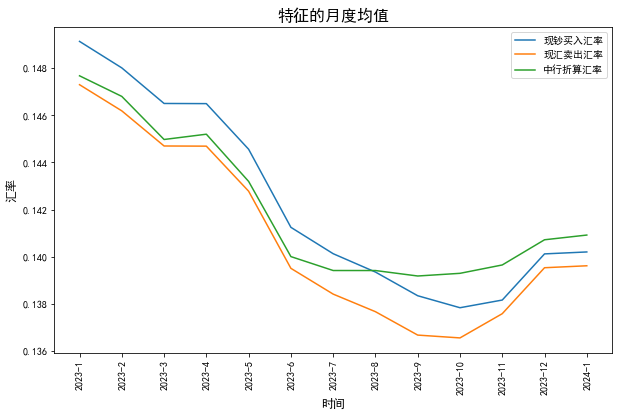

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

# 创建一个新的图形
plt.figure(figsize=(10, 6))

# 遍历每个特征
for feature in ['现钞买入汇率', '现汇卖出汇率', '中行折算汇率']:
    # 绘制折线图
    plt.plot(avg_price_monthly.index.map(lambda x: f"{x[0]}-{x[1]}"), avg_price_monthly[feature], label=feature)

# 设置横坐标标签
plt.xticks(rotation=90)

# 设置标题和轴标签
plt.title('特征的月度均值', fontsize=16)
plt.xlabel("时间", fontsize=12)
plt.ylabel('汇率', fontsize=12)

# 添加图例
plt.legend()

# 显示图形
plt.show() 

In [22]:
avg_price['年份'] = avg_price.index.year.astype(int)
avg_price['月份'] = avg_price.index.month.astype(int)
avg_price['日'] = avg_price.index.day.astype(int)
# avg_price_day = avg_price.groupby(['年份', '月份', '日']) 
avg_price.head() 

,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,现钞买入汇率,现汇卖出汇率,中行折算汇率,汇率变化率,年份,月份,日期,日
发布时间,,,,,,,,,,,,,
2023-01-09,676.967015,671.460373,679.834179,679.834179,683.084552,0.148929,0.147095,0.146395,0.00000,2023,1,1673222400000000000,9
2023-01-10,676.236846,670.734808,679.099462,679.099462,676.688538,0.149090,0.147254,0.147778,0.93634,2023,1,1673308800000000000,10
2023-01-11,676.282905,670.779333,679.144619,679.144619,677.497857,0.149080,0.147244,0.147602,-0.11960,2023,1,1673395200000000000,11
2023-01-12,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.09914,2023,1,1673481600000000000,12
2023-01-13,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023,1,1673568000000000000,13


In [23]:
import matplotlib.pyplot as plt

# 创建12张子图
#fig, axes = plt.subplots(4, 3, figsize=(12, 12))

avg_price_day1 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 1)]
avg_price_day2 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 2)]
avg_price_day3 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 3)]
avg_price_day4 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 4)]
avg_price_day5 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 5)]
avg_price_day6 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 6)]
avg_price_day7 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 7)]
avg_price_day8 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 8)]
avg_price_day9 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 9)]
avg_price_day10 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 10)]
avg_price_day11 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 11)]
avg_price_day12 = avg_price[(avg_price['年份'] == 2023) & (avg_price['月份'] == 12)]
avg_price_day13 = avg_price[(avg_price['年份'] == 2024) & (avg_price['月份'] == 1)]


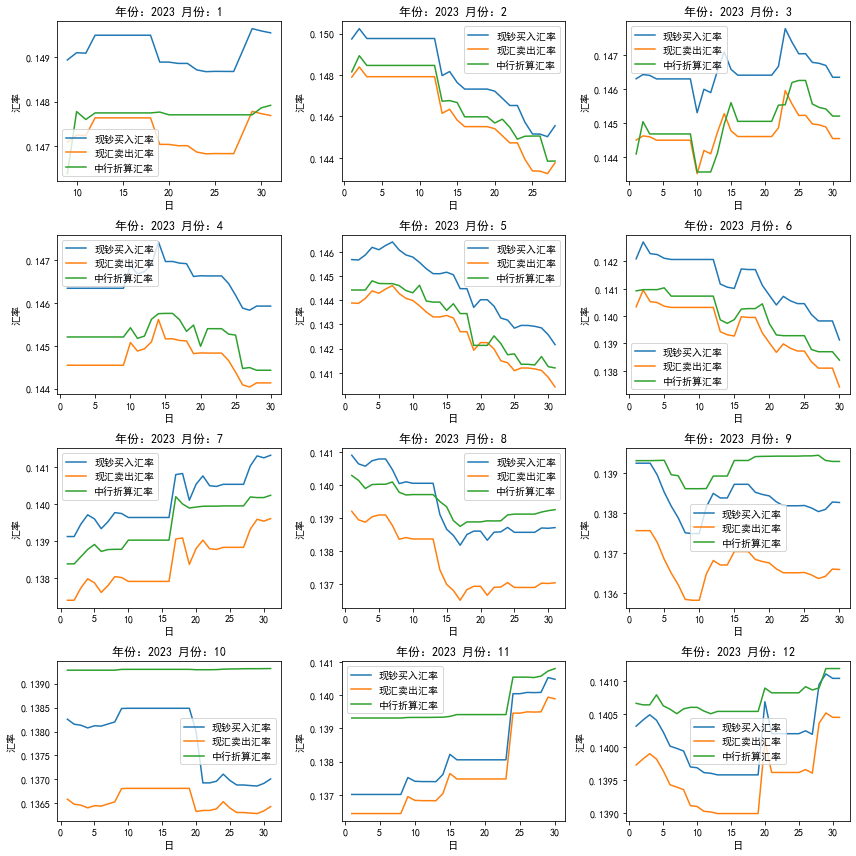

<Figure size 432x288 with 0 Axes>

In [24]:
# 创建12张子图
fig, axes = plt.subplots(4, 3, figsize=(12, 12))

# 设置子图标题和坐标轴标签
axes[0, 0].plot(avg_price_day1['日'], avg_price_day1['现钞买入汇率'], label='现钞买入汇率')
axes[0, 0].plot(avg_price_day1['日'], avg_price_day1['现汇卖出汇率'], label='现汇卖出汇率')
axes[0, 0].plot(avg_price_day1['日'], avg_price_day1['中行折算汇率'], label='中行折算汇率')
axes[0, 0].set_title('年份：2023 月份：1')
axes[0, 0].set_xlabel('日')
axes[0, 0].set_ylabel('汇率')
axes[0, 0].legend()

axes[0, 1].plot(avg_price_day2['日'], avg_price_day2['现钞买入汇率'], label='现钞买入汇率')
axes[0, 1].plot(avg_price_day2['日'], avg_price_day2['现汇卖出汇率'], label='现汇卖出汇率')
axes[0, 1].plot(avg_price_day2['日'], avg_price_day2['中行折算汇率'], label='中行折算汇率')
axes[0, 1].set_title('年份：2023 月份：2')
axes[0, 1].set_xlabel('日')
axes[0, 1].set_ylabel('汇率')
axes[0, 1].legend()

axes[0, 2].plot(avg_price_day3['日'], avg_price_day3['现钞买入汇率'], label='现钞买入汇率')
axes[0, 2].plot(avg_price_day3['日'], avg_price_day3['现汇卖出汇率'], label='现汇卖出汇率')
axes[0, 2].plot(avg_price_day3['日'], avg_price_day3['中行折算汇率'], label='中行折算汇率')
axes[0, 2].set_title('年份：2023 月份：3')
axes[0, 2].set_xlabel('日')
axes[0, 2].set_ylabel('汇率')
axes[0, 2].legend()

axes[1, 0].plot(avg_price_day4['日'], avg_price_day4['现钞买入汇率'], label='现钞买入汇率')
axes[1, 0].plot(avg_price_day4['日'], avg_price_day4['现汇卖出汇率'], label='现汇卖出汇率')
axes[1, 0].plot(avg_price_day4['日'], avg_price_day4['中行折算汇率'], label='中行折算汇率')
axes[1, 0].set_title('年份：2023 月份：4')
axes[1, 0].set_xlabel('日')
axes[1, 0].set_ylabel('汇率')
axes[1, 0].legend()

axes[1, 1].plot(avg_price_day5['日'], avg_price_day5['现钞买入汇率'], label='现钞买入汇率')
axes[1, 1].plot(avg_price_day5['日'], avg_price_day5['现汇卖出汇率'], label='现汇卖出汇率')
axes[1, 1].plot(avg_price_day5['日'], avg_price_day5['中行折算汇率'], label='中行折算汇率')
axes[1, 1].set_title('年份：2023 月份：5')
axes[1, 1].set_xlabel('日')
axes[1, 1].set_ylabel('汇率')
axes[1, 1].legend()

# 继续为每个月份绘制子图...

axes[1, 2].plot(avg_price_day6['日'], avg_price_day6['现钞买入汇率'], label='现钞买入汇率')
axes[1, 2].plot(avg_price_day6['日'], avg_price_day6['现汇卖出汇率'], label='现汇卖出汇率')
axes[1, 2].plot(avg_price_day6['日'], avg_price_day6['中行折算汇率'], label='中行折算汇率')
axes[1, 2].set_title('年份：2023 月份：6')
axes[1, 2].set_xlabel('日')
axes[1, 2].set_ylabel('汇率')
axes[1, 2].legend()

axes[2, 0].plot(avg_price_day7['日'], avg_price_day7['现钞买入汇率'], label='现钞买入汇率')
axes[2, 0].plot(avg_price_day7['日'], avg_price_day7['现汇卖出汇率'], label='现汇卖出汇率')
axes[2, 0].plot(avg_price_day7['日'], avg_price_day7['中行折算汇率'], label='中行折算汇率')
axes[2, 0].set_title('年份：2023 月份：7')
axes[2, 0].set_xlabel('日')
axes[2, 0].set_ylabel('汇率')
axes[2, 0].legend()

axes[2, 1].plot(avg_price_day8['日'], avg_price_day8['现钞买入汇率'], label='现钞买入汇率')
axes[2, 1].plot(avg_price_day8['日'], avg_price_day8['现汇卖出汇率'], label='现汇卖出汇率')
axes[2, 1].plot(avg_price_day8['日'], avg_price_day8['中行折算汇率'], label='中行折算汇率')
axes[2, 1].set_title('年份：2023 月份：8')
axes[2, 1].set_xlabel('日')
axes[2, 1].set_ylabel('汇率')
axes[2, 1].legend()

axes[2, 2].plot(avg_price_day9['日'], avg_price_day9['现钞买入汇率'], label='现钞买入汇率')
axes[2, 2].plot(avg_price_day9['日'], avg_price_day9['现汇卖出汇率'], label='现汇卖出汇率')
axes[2, 2].plot(avg_price_day9['日'], avg_price_day9['中行折算汇率'], label='中行折算汇率')
axes[2, 2].set_title('年份：2023 月份：9')
axes[2, 2].set_xlabel('日')
axes[2, 2].set_ylabel('汇率')
axes[2, 2].legend()

axes[3, 0].plot(avg_price_day10['日'], avg_price_day10['现钞买入汇率'], label='现钞买入汇率')
axes[3, 0].plot(avg_price_day10['日'], avg_price_day10['现汇卖出汇率'], label='现汇卖出汇率')
axes[3, 0].plot(avg_price_day10['日'], avg_price_day10['中行折算汇率'], label='中行折算汇率')
axes[3, 0].set_title('年份：2023 月份：10')
axes[3, 0].set_xlabel('日')
axes[3, 0].set_ylabel('汇率')
axes[3, 0].legend()

axes[3, 1].plot(avg_price_day11['日'], avg_price_day11['现钞买入汇率'], label='现钞买入汇率')
axes[3, 1].plot(avg_price_day11['日'], avg_price_day11['现汇卖出汇率'], label='现汇卖出汇率')
axes[3, 1].plot(avg_price_day11['日'], avg_price_day11['中行折算汇率'], label='中行折算汇率')
axes[3, 1].set_title('年份：2023 月份：11')
axes[3, 1].set_xlabel('日')
axes[3, 1].set_ylabel('汇率')
axes[3, 1].legend()

axes[3, 2].plot(avg_price_day12['日'], avg_price_day12['现钞买入汇率'], label='现钞买入汇率')
axes[3, 2].plot(avg_price_day12['日'], avg_price_day12['现汇卖出汇率'], label='现汇卖出汇率')
axes[3, 2].plot(avg_price_day12['日'], avg_price_day12['中行折算汇率'], label='中行折算汇率')
axes[3, 2].set_title('年份：2023 月份：12')
axes[3, 2].set_xlabel('日')
axes[3, 2].set_ylabel('汇率')
axes[3, 2].legend()


# 调整子图间距
plt.tight_layout()

# 显示图形
plt.show() 
plt.savefig('aaa.png')

In [25]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

result_df = pd.read_csv('result.csv')
columns = ['现汇买入价', '现钞买入价', '现汇卖出价', '现钞卖出价', '中行折算价', '发布时间']
result_df = pd.read_csv('result.csv', names = columns)
result_df.drop("0", axis=0,inplace=True)
result_df.drop("货币名称", axis=0, inplace=True)
result_df['发布时间'] = pd.to_datetime(result_df['发布时间'])
result_df['发布时间'] = result_df['发布时间'].dt.date
result_df
result_df = result_df.reset_index(drop=True)
result_df = result_df.astype(
{
"现汇买入价": "float",
"现钞买入价": "float",
"现汇卖出价": "float",
"现钞卖出价": "float",
"中行折算价": "float",
}
)
result_df = result_df.groupby(["发布时间"], sort=True)
avg_price = result_df.mean()
avg_price['现钞买入汇率'] = 100.0 / avg_price['现钞买入价']
avg_price['现汇卖出汇率'] = 100.0 / avg_price['现汇卖出价']
avg_price['中行折算汇率'] = 100.0 / avg_price['中行折算价']
avg_price.index = pd.to_datetime(avg_price.index)
avg_price = avg_price.resample("D").ffill()
avg_price['汇率变化率'] = ((avg_price['中行折算汇率'] - avg_price['中行折算汇率'].shift(1))/(avg_price['中行折算汇率']))*100
avg_price['汇率变化率'] = avg_price['汇率变化率'].round(5)
avg_price['汇率变化率'][0] = 0
avg_price['日期'] = avg_price.index
avg_price


,现汇买入价,现钞买入价,现汇卖出价,现钞卖出价,中行折算价,现钞买入汇率,现汇卖出汇率,中行折算汇率,汇率变化率,日期
发布时间,,,,,,,,,,
2023-01-09,676.967015,671.460373,679.834179,679.834179,683.084552,0.148929,0.147095,0.146395,0.00000,2023-01-09
2023-01-10,676.236846,670.734808,679.099462,679.099462,676.688538,0.149090,0.147254,0.147778,0.93634,2023-01-10
2023-01-11,676.282905,670.779333,679.144619,679.144619,677.497857,0.149080,0.147244,0.147602,-0.11960,2023-01-11
2023-01-12,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.09914,2023-01-12
2023-01-13,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023-01-13
2023-01-14,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023-01-14
2023-01-15,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023-01-15
2023-01-16,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023-01-16
2023-01-17,674.472000,668.984966,677.331724,677.331724,676.826207,0.149480,0.147638,0.147748,0.00000,2023-01-17


C:\ana3\lib\site-packages\pandas\plotting\_compat.py:57: MatplotlibDeprecationWarning: 
The compare_versions function was deprecated in Matplotlib 3.2 and will be removed two minor releases later.
  return matplotlib.compare_versions('2.0.0', matplotlib.__version__)


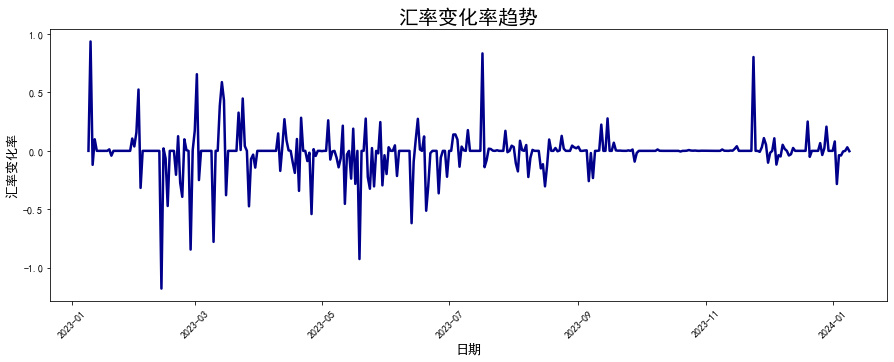

In [26]:
import matplotlib.pyplot as plt
# 绘制汇率变化率的折线图
plt.figure(figsize=(15, 5))
plt.plot(avg_price.index, avg_price['汇率变化率'], color='darkblue', linewidth=2.5)
plt.xlabel('日期', fontsize=13)
plt.ylabel('汇率变化率', fontsize=13)
plt.title('汇率变化率趋势', fontsize=20)
plt.xticks(rotation=45)
plt.show() 


In [93]:
from sklearn.preprocessing import StandardScaler

# 假设您的特征数据存储在X中，目标值存储在y中
X = avg_price[['现钞买入汇率', '现汇卖出汇率', '中行折算汇率']]
y = avg_price['汇率变化率']

scaler = StandardScaler() 

X_prepared = scaler.fit_transform(X) 

In [94]:
from sklearn.model_selection import train_test_split
import numpy as np


# 使用train_test_split函数将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_prepared, y, test_size=0.5, random_state=42)



In [100]:
'''from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
lin = LinearRegression()
scores1 = cross_val_score(lin,
                        X_train, y_train,
                        scoring="neg_mean_squared_error",
                        cv=5)
scores1 = -scores1
scores1.mean()  
'''

'from sklearn.linear_model import LinearRegression\nfrom sklearn.model_selection import cross_val_score\nlin = LinearRegression()\nscores1 = cross_val_score(lin,\n                        X_train, y_train,\n                        scoring="neg_mean_squared_error",\n                        cv=5)\nscores1 = -scores1\nscores1.mean()  \n'

In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lin = LinearRegression() 

lin.fit(X_prepared, y)
y_test_predicted = lin.predict(X_test)

lin_mean = mean_squared_error(y_pred=y_test_predicted, y_true=y_test)
print(f"均方误差MSE：{lin_mean}") 

均方误差MSE：0.020094089674305097


In [105]:
from sklearn.linear_model import LinearRegression
import numpy as np

print("模型系数: ", lin.coef_)
print("决定系数: %.2f" % lin.score(X_test, y_test))
print("train score:", lin.score(X_train, y_train))


模型系数:  [-0.11303267  0.04977897  0.06334074]
决定系数: 0.02
train score: 0.0059195913552778645


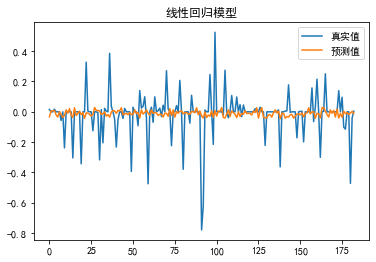

In [106]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label='真实值')
plt.plot(y_pred, label='预测值')
plt.title('线性回归模型')
plt.legend()
plt.show() 

In [127]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=20)

tree.fit(X_prepared, y)
y_pred = tree.predict(X_test)

# 计算模型的准确率
tree_mean = mean_squared_error(y_pred=y_pred, y_true=y_test)
accuracy = tree.score(X_test, y_test)
print(f"均方误差MSE：{tree_mean}")
print("模型准确率: %.2f" % accuracy)


均方误差MSE：0.002745579304074299
模型准确率: 0.87


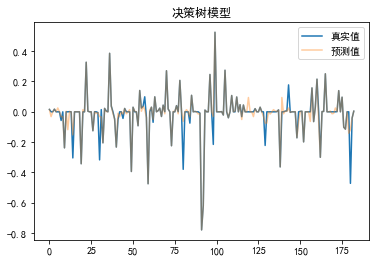

In [128]:
# 绘制真实值与预测值的对比折线图
plt.plot(y_test.values, label='真实值')
plt.plot(y_pred, label='预测值', alpha=0.4)
plt.title('决策树模型')
plt.legend()
plt.show() 

In [150]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, max_depth=100)

model.fit(X_prepared, y)
y_pred = model.predict(X_test)

# 计算模型的准确率
model_mean = mean_squared_error(y_pred=y_pred, y_true=y_test)
accuracy = model.score(X_test, y_test)
print(f"均方误差MSE：{model_mean}")
print("模型准确率: %.2f" % accuracy)


均方误差MSE：0.006364063501489956
模型准确率: 0.69


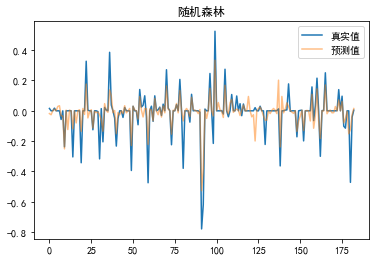

In [151]:
# 绘制真实值与预测值的对比折线图
plt.plot(y_test.values, label='真实值')
plt.plot(y_pred, label='预测值', alpha=0.5)
plt.title('随机森林')
plt.legend()
plt.show() 